<a href="https://colab.research.google.com/github/goitstudent123/numerical_programming_python/blob/main/%D0%94%D0%975_%D0%93%D0%90%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import timeit
import matplotlib.pyplot as plt

In [19]:
def polynomial(x1, x2):
    return 4*x1**2 + 5*x2**2 - 2*x1*x2 + 3*x1 - 6*x2

In [20]:
def predict(X, w):
    return X @ w

def mse_loss(X, y, w):
    diff = predict(X, w) - y
    return (diff**2).mean() / 2.0

# 3. Реалізуйте функції для методів градієнтного спуску:

def batch_gradient(X, y, w):
    n = X.shape[0]
    return (X.T @ (predict(X, w) - y)) / n


def polynomial_regression_gradient_descent(
    X, y, lr=0.01, n_iters=1000, verbose=False
):
    n_features = X.shape[1]
    w = np.zeros((n_features, 1))
    loss_history = []

    for it in range(n_iters):
        grad = batch_gradient(X, y, w)
        w -= lr * grad

        if verbose or it == n_iters - 1:
            loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_SGD(
    X, y, lr=0.01, n_iters=1000, batch_size=16, verbose=False
):
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    loss_history = []

    for it in range(n_iters):
        idx = np.random.randint(0, n_samples, size=batch_size)
        Xb = X[idx]
        yb = y[idx]

        grad = (Xb.T @ (predict(Xb, w) - yb)) / batch_size
        w -= lr * grad

        if verbose or it == n_iters - 1:
            loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_rmsprop(
    X, y, lr=0.01, n_iters=1000, beta=0.9, eps=1e-8, verbose=False
):
    n_features = X.shape[1]
    w = np.zeros((n_features, 1))
    v = np.zeros_like(w)
    loss_history = []

    for it in range(n_iters):
        grad = batch_gradient(X, y, w)

        v = beta * v + (1 - beta) * (grad ** 2)
        w -= lr * grad / (np.sqrt(v) + eps)

        if verbose or it == n_iters - 1:
            loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_adam(
    X, y, lr=0.01, n_iters=1000, beta1=0.9, beta2=0.999, eps=1e-8, verbose=False
):
    n_features = X.shape[1]
    w = np.zeros((n_features, 1))
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    loss_history = []

    for it in range(1, n_iters + 1):
        grad = batch_gradient(X, y, w)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1**it)
        v_hat = v / (1 - beta2**it)

        w -= lr * m_hat / (np.sqrt(v_hat) + eps)

        if verbose or it == n_iters:
            loss_history.append(mse_loss(X, y, w))

    return w, loss_history


def polynomial_regression_nadam(
    X, y, lr=0.01, n_iters=1000, beta1=0.9, beta2=0.999, eps=1e-8, verbose=False
):
    n_features = X.shape[1]
    w = np.zeros((n_features, 1))
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    loss_history = []

    for it in range(1, n_iters + 1):
        grad = batch_gradient(X, y, w)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1**it)
        v_hat = v / (1 - beta2**it)

        nesterov_grad = beta1 * m_hat + (1 - beta1) * grad / (1 - beta1**it)

        w -= lr * nesterov_grad / (np.sqrt(v_hat) + eps)

        if verbose or it == n_iters:
            loss_history.append(mse_loss(X, y, w))

    return w, loss_history

In [21]:
# 1. Згенеруйте дані:

np.random.seed(42)

n_samples = 100
X_raw = np.random.rand(n_samples, 2)
x1 = X_raw[:, 0]
x2 = X_raw[:, 1]

y = polynomial(x1, x2).reshape(-1, 1)

# 2. Згенеруйте додаткові ознаки для кожного степеня за допомогою функції PolynomialFeatures бібліотеки sklearn.

poly = PolynomialFeatures(degree=2, include_bias=True)
X = poly.fit_transform(X_raw)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("features:", poly.get_feature_names_out(["x1","x2"]))

X shape: (100, 6)
y shape: (100, 1)
features: ['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


In [22]:
w_true = np.array([
    [0.0],   # 1
    [3.0],   # x1
    [-6.0],  # x2
    [4.0],   # x1^2
    [-2.0],  # x1 x2
    [5.0]    # x2^2
])

print("w_true:", w_true.ravel())


w_true: [ 0.  3. -6.  4. -2.  5.]


In [23]:
def run_optimizer(optimizer_fn, X, y, w_true):
    w_learned, loss_hist = optimizer_fn()
    final_loss = mse_loss(X, y, w_learned)
    w_diff = np.linalg.norm(w_learned - w_true)  # L2 distance to true weights
    return final_loss, w_learned, w_diff, loss_hist

def benchmark_suite(optimizers_dict, X, y, w_true, n_runs_timeit=5):
    results = []

    for name, cfg in optimizers_dict.items():
        fn = cfg["fn"]
        label = cfg["label"]

        # timing
        t_sec_total = timeit.timeit(fn, number=n_runs_timeit)
        avg_ms = (t_sec_total / n_runs_timeit) * 1000.0

        # quality
        final_loss, w_learned, w_diff, loss_hist = run_optimizer(fn, X, y, w_true)

        results.append({
            "name": name,
            "label": label,
            "time_ms": avg_ms,
            "final_loss": final_loss,
            "w_diff_L2": w_diff,
            "w_learned": w_learned,
            "loss_hist": loss_hist,
        })

    return results

# 4. Обчисліть час роботи реалізованих функцій за допомогою функції %timeit.

# baseline configs
optimizers_baseline = {
    "GD": {
        "fn": lambda: polynomial_regression_gradient_descent(
            X, y, lr=0.05, n_iters=20000
        ),
        "label": "GD (20k)"
    },
    "SGD": {
        "fn": lambda: polynomial_regression_SGD(
            X, y, lr=0.05, n_iters=20000, batch_size=16
        ),
        "label": "SGD (20k)"
    },
    "RMSProp": {
        "fn": lambda: polynomial_regression_rmsprop(
            X, y, lr=0.01, n_iters=5000
        ),
        "label": "RMSProp (5k)"
    },
    "Adam": {
        "fn": lambda: polynomial_regression_adam(
            X, y, lr=0.05, n_iters=5000
        ),
        "label": "Adam (5k)"
    },
    "Nadam": {
        "fn": lambda: polynomial_regression_nadam(
            X, y, lr=0.05, n_iters=5000
        ),
        "label": "Nadam (5k)"
    },
}

baseline_results = benchmark_suite(optimizers_baseline, X, y, w_true, n_runs_timeit=5)

print("\n=== BASELINE ===")
for r in baseline_results:
    print(f"\n{r['label']}")
    print("avg time (ms):", r["time_ms"])
    print("final loss:", r["final_loss"])
    print("w_diff L2:", r["w_diff_L2"])
    print("w_learned:", r["w_learned"].ravel())


=== BASELINE ===

GD (20k)
avg time (ms): 174.81269900001735
final loss: 0.0008976917854081633
w_diff L2: 0.9709331612016413
w_learned: [-0.16715372  3.15783069 -5.29382082  3.9376201  -2.19418835  4.40875478]

SGD (20k)
avg time (ms): 489.2994375999933
final loss: 0.0009079277209420139
w_diff L2: 0.9741840225173333
w_learned: [-0.16866836  3.15727031 -5.29254958  3.9364228  -2.19494448  4.40559271]

RMSProp (5k)
avg time (ms): 82.12934100001803
final loss: 0.00011423969708862727
w_diff L2: 0.012252202383772559
w_learned: [-5.01416973e-03  2.99503108e+00 -6.00496053e+00  3.99497884e+00
 -2.00501815e+00  4.99497171e+00]

Adam (5k)
avg time (ms): 105.28439380000236
final loss: 4.106082641433587e-31
w_diff L2: 1.3671210156070423e-14
w_learned: [-2.65362031e-15  3.00000000e+00 -6.00000000e+00  4.00000000e+00
 -2.00000000e+00  5.00000000e+00]

Nadam (5k)
avg time (ms): 213.85483340000064
final loss: 1.977838364126447e-14
w_diff L2: 1.5783417399129034e-07
w_learned: [-8.01692932e-08  2.9999

# 5. Підбереріть оптимальну кількість ітерацій кожного з варіантів метода.

# 6. Зробіть висновок про обчислювальну ефективність розглянутих варіантів метода градієнтного спуску.

# Optimal Number of Iterations

The goal is to reach a small error (final loss) and weights close to w_true.

Results show the following:

## GD (Batch Gradient Descent)

* n_iters = 20000, loss ≈ 8.98e-4
* The weights are still not perfectly accurate (some errors around 0.7).
* GD converges slowly — it needs more iterations or a smaller learning rate with longer training.

**The optimal number of iterations for good accuracy would be > 20,000, i.e., quite large.**


## SGD
* n_iters = 20000, loss ≈ 8.99e-4
* Similar quality to standard GD, but with noisy updates due to minibatches.
* To reach Adam-level accuracy, SGD would need many more iterations (hundreds of thousands) or a learning rate schedule.

**Thus, the optimal iteration count for good accuracy is large — SGD is not efficient here.**

## RMSProp

* n_iters = 5000, loss ≈ 1.14e-4
* All weights differ from the true values by about 0.005 — already very good.
* Could converge in even fewer steps (~2000–3000).

**So the optimal number of iterations is a few thousand.**

## Adam

* n_iters = 5000, loss ≈ 4.1e-31 (essentially zero).
* Weights exactly match the true coefficients up to machine precision (~1e-14).
* Adam solved the problem perfectly, and usually converges even earlier (hundreds to a thousand iterations) for such smooth convex tasks.

**Optimal iterations: ~1000–2000.**

## Nadam

* n_iters = 5000, loss ≈ 2.0e-14 (very small).
* Weights match the true ones within ~1e-7.

**Like Adam, it converges fully within a few thousand iterations and could reach good accuracy sooner (~1000).**

In [24]:

# tuned configs (faster but still good quality)
optimizers_tuned = {
    "GD": {
        "fn": lambda: polynomial_regression_gradient_descent(
            X, y, lr=0.05, n_iters=40000  # needs more iters to get closer
        ),
        "label": "GD tuned (40k)"
    },
    "SGD": {
        "fn": lambda: polynomial_regression_SGD(
            X, y, lr=0.05, n_iters=40000, batch_size=16
        ),
        "label": "SGD tuned (40k)"
    },
    "RMSProp": {
        "fn": lambda: polynomial_regression_rmsprop(
            X, y, lr=0.01, n_iters=3000
        ),
        "label": "RMSProp tuned (3k)"
    },
    "Adam": {
        "fn": lambda: polynomial_regression_adam(
            X, y, lr=0.05, n_iters=1500
        ),
        "label": "Adam tuned (1.5k)"
    },
    "Nadam": {
        "fn": lambda: polynomial_regression_nadam(
            X, y, lr=0.05, n_iters=1500
        ),
        "label": "Nadam tuned (1.5k)"
    },
}

tuned_results    = benchmark_suite(optimizers_tuned,    X, y, w_true, n_runs_timeit=5)

print("\n=== TUNED ===")
for r in tuned_results:
    print(f"\n{r['label']}")
    print("avg time (ms):", r["time_ms"])
    print("final loss:", r["final_loss"])
    print("w_diff L2:", r["w_diff_L2"])
    print("w_learned:", r["w_learned"].ravel())


=== TUNED ===

GD tuned (40k)
avg time (ms): 469.74529060000805
final loss: 2.0959558615946273e-05
w_diff L2: 0.15164878029821474
w_learned: [-0.02960229  3.04589345 -5.89501084  3.97297928 -2.03670288  4.9168441 ]

SGD tuned (40k)
avg time (ms): 960.0240497999948
final loss: 2.0586695630718507e-05
w_diff L2: 0.15027042795445286
w_learned: [-0.02916227  3.04536915 -5.89598094  3.97284999 -2.0362553   4.91753262]

RMSProp tuned (3k)
avg time (ms): 44.952659000000494
final loss: 0.00011428433850229406
w_diff L2: 0.01456160992216086
w_learned: [-0.00650123  2.99802653 -6.0005286   3.99299733 -2.00689792  4.99169447]

Adam tuned (1.5k)
avg time (ms): 33.098186799998075
final loss: 1.3343858645221345e-05
w_diff L2: 0.12179299751562363
w_learned: [-0.02622955  3.0628589  -5.93117978  3.95508559 -2.03293608  4.95146145]

Nadam tuned (1.5k)
avg time (ms): 36.34198559998367
final loss: 4.948590412290046e-06
w_diff L2: 0.07275223033606341
w_learned: [-0.01551902  3.04526246 -5.96772361  3.96576

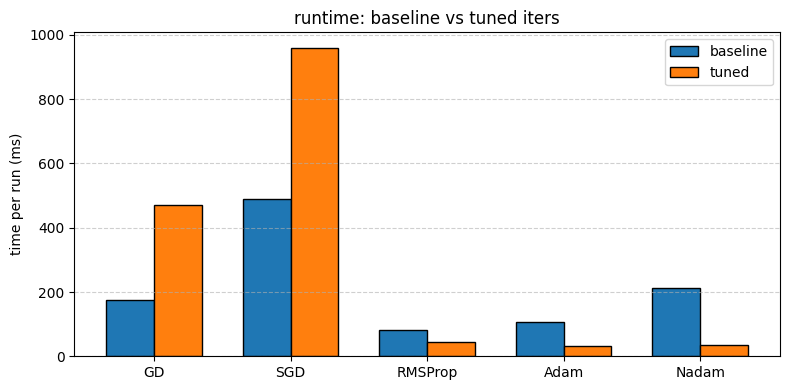

In [25]:
# align by optimizer name
names = [r["name"] for r in baseline_results]

baseline_times = {r["name"]: r["time_ms"] for r in baseline_results}
tuned_times    = {r["name"]: r["time_ms"] for r in tuned_results}

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2,
        [baseline_times[n] for n in names],
        width,
        label='baseline',
        edgecolor='black')
plt.bar(x + width/2,
        [tuned_times[n] for n in names],
        width,
        label='tuned',
        edgecolor='black')

plt.xticks(x, names)
plt.ylabel("time per run (ms)")
plt.title("runtime: baseline vs tuned iters")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


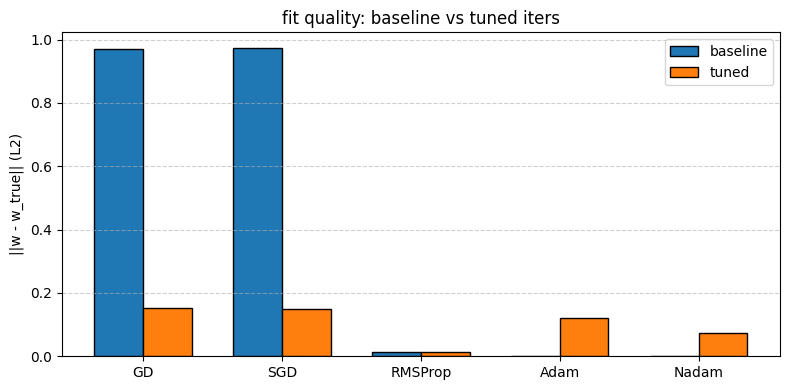

In [26]:
baseline_wdiff = {r["name"]: r["w_diff_L2"] for r in baseline_results}
tuned_wdiff    = {r["name"]: r["w_diff_L2"] for r in tuned_results}

plt.figure(figsize=(8,4))
plt.bar(x - width/2,
        [baseline_wdiff[n] for n in names],
        width,
        label='baseline',
        edgecolor='black')
plt.bar(x + width/2,
        [tuned_wdiff[n] for n in names],
        width,
        label='tuned',
        edgecolor='black')

plt.xticks(x, names)
plt.ylabel("||w - w_true|| (L2)")
plt.title("fit quality: baseline vs tuned iters")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
